# 📊 Online Retail Analysis - Part 1: Data Loading & Exploration

**Project:** E-Commerce Transaction Analysis  
**Dataset:** Online Retail II (UCI/Kaggle)  
**Objective:** Load and perform initial exploration of retail transaction data

---

## 🎯 Business Context
This analysis examines online retail transactions to understand:
- Customer purchasing patterns
- Product performance
- Sales trends
- Data quality issues

**Key Questions:**
- What does our data look like?
- Are there quality issues?
- What's the time range?
- How many customers and products?

## 1️⃣ Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2️⃣ Load Dataset

In [2]:
# Load data from CSV
df = pd.read_csv('data/online_retail_II.csv', encoding='ISO-8859-1')

print(f"✓ Dataset loaded successfully!")
print(f"📦 Total records: {len(df):,}")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Dataset loaded successfully!
📦 Total records: 1,067,371
📊 Shape: 1,067,371 rows × 8 columns


## 3️⃣ Initial Data Inspection

In [3]:
# Display first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [4]:
# Dataset information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.info()

DATASET INFORMATION

Shape: 1,067,371 rows × 8 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


## 4️⃣ Data Quality Check

In [6]:
# Check for missing values
print(" Missing Values Analysis:")
print("=" * 50)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("✓ No missing values found!")

 Missing Values Analysis:
     Column  Missing Count  Missing %
Customer ID         243007      22.77
Description           4382       0.41


In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate Rows: {duplicates:,}")
if duplicates > 0:
    print(f"   ({(duplicates/len(df)*100):.2f}% of total data)")


🔄 Duplicate Rows: 34,335
   (3.22% of total data)


## 5️⃣ Dataset Overview

In [8]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Key metrics
print("Dataset Overview:")
print("=" * 50)
print(f"Total Transactions: {len(df):,}")
print(f"Unique Invoices: {df['Invoice'].nunique():,}")
print(f"Unique Products: {df['StockCode'].nunique():,}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
print(f"Countries Served: {df['Country'].nunique()}")
print(f"\nDate Range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Time Period: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Dataset Overview:
Total Transactions: 1,067,371
Unique Invoices: 53,628
Unique Products: 5,305
Unique Customers: 5,942
Countries Served: 43

Date Range: 2009-12-01 to 2011-12-09
Time Period: 738 days


# Top 10 countries
print("\nTop 10 Countries by Transaction Volume:")
print("=" * 50)
country_dist = df['Country'].value_counts().head(10)
for country, count in country_dist.items():
    print(f"{country:25} : {count:,} ({count/len(df)*100:.1f}%)")

## 6️⃣ Initial Visualizations

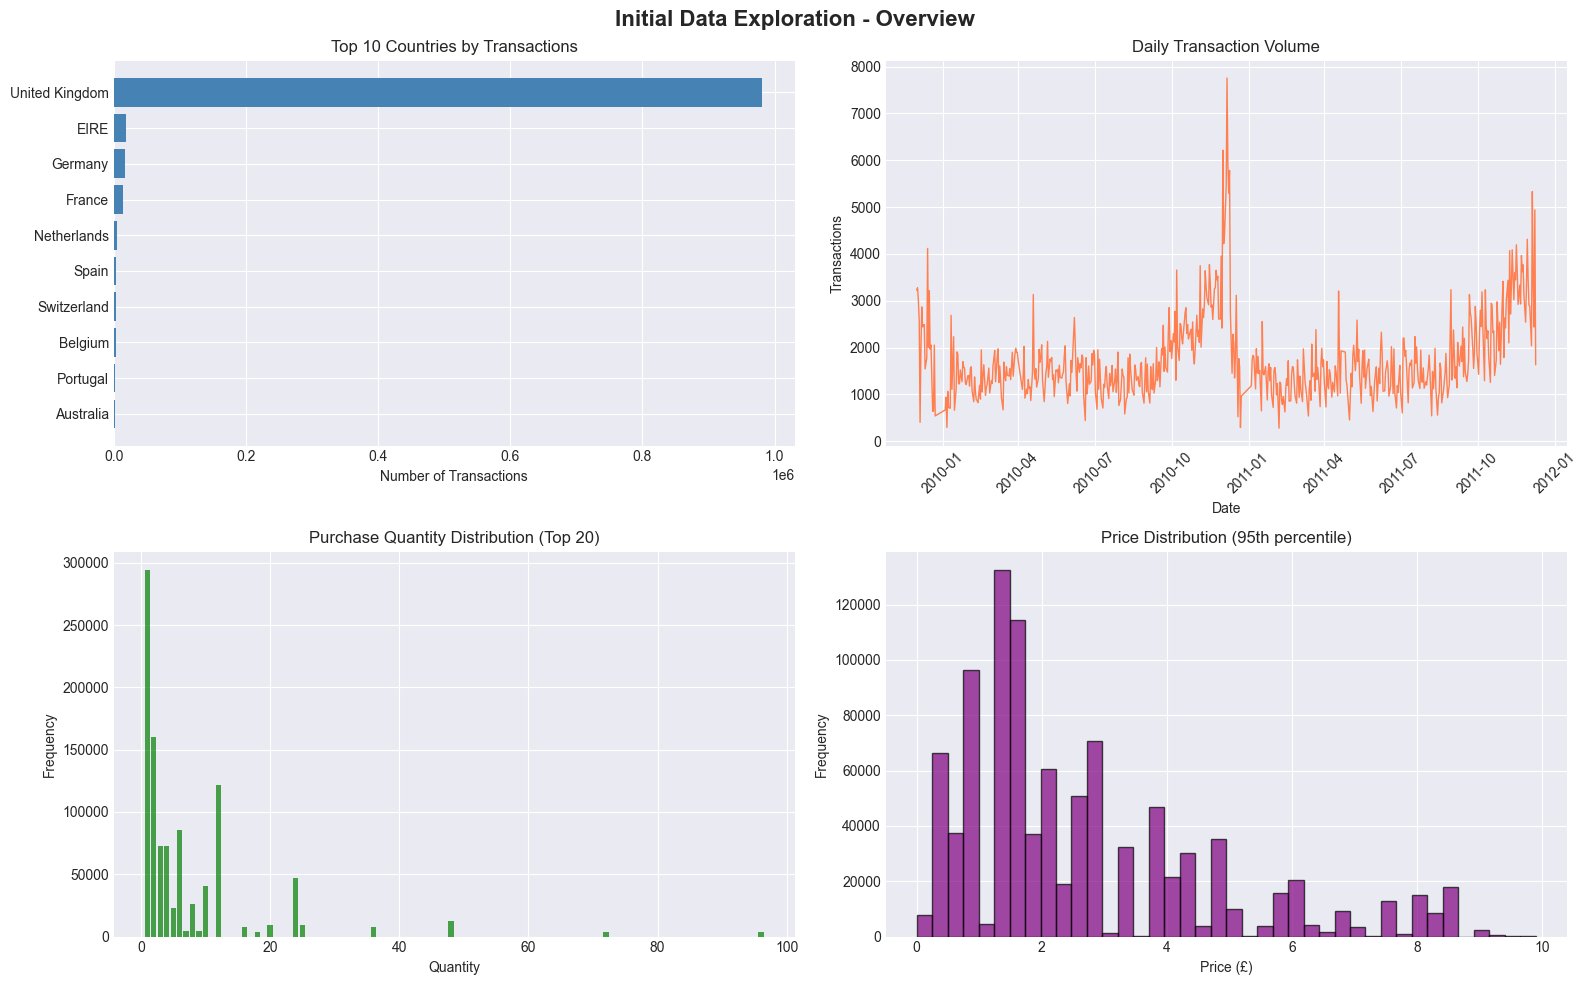

✓ Visualization saved to outputs/figures/


In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Initial Data Exploration - Overview', fontsize=16, fontweight='bold')

# 1. Top 10 Countries
country_counts = df['Country'].value_counts().head(10)
axes[0, 0].barh(country_counts.index, country_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_title('Top 10 Countries by Transactions')
axes[0, 0].invert_yaxis()

# 2. Transactions over time (daily)
daily_trans = df.groupby(df['InvoiceDate'].dt.date).size()
axes[0, 1].plot(daily_trans.index, daily_trans.values, color='coral', linewidth=1)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Transactions')
axes[0, 1].set_title('Daily Transaction Volume')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Quantity distribution (positive only)
quantity_dist = df[df['Quantity'] > 0]['Quantity'].value_counts().head(20).sort_index()
axes[1, 0].bar(quantity_dist.index, quantity_dist.values, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Quantity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Purchase Quantity Distribution (Top 20)')

# 4. Price distribution (positive only)
price_data = df[df['Price'] > 0]['Price']
axes[1, 1].hist(price_data[price_data < price_data.quantile(0.95)], 
                bins=40, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Price (£)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Price Distribution (95th percentile)')

plt.tight_layout()
plt.savefig('outputs/figures/01_initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to outputs/figures/")

## 7️⃣ Key Findings

### ✅ Data Quality Observations:
1. **Missing Values**: Some Customer IDs are missing
2. **Data Range**: Multi-year transaction history
3. **Geographic Coverage**: Strong UK presence with international reach

###  Initial Insights:
1. **Market Focus**: Majority of transactions from United Kingdom
2. **Product Variety**: Thousands of unique products
3. **Customer Base**: Large customer base across multiple countries
4. **Transaction Patterns**: Daily variations in activity

###  Next Steps:
1. Data cleaning and preprocessing
2. Handle missing values
3. Remove invalid transactions
4. Feature engineering for deeper analysis

## 💾 Save Checkpoint

In [10]:
# Save raw data for next notebook
df.to_pickle('data/checkpoint_01_raw.pkl')
print("✓ Data checkpoint saved successfully!")
print(" Location: data/checkpoint_01_raw.pkl")

✓ Data checkpoint saved successfully!
 Location: data/checkpoint_01_raw.pkl
